# β-VAE Latent Space Variance Analysis

**Two experiments in main body of text in paper:**
- **Experiment 1 (Leave-One-Out):** Replace LD_k with its mean (or zero) and measure the fraction of reconstruction variance that is *lost*.
- **Experiment 2 (Isolated Contribution):** Set all LDs to mean (or zero) *except* LD_k and measure how much variance LD_k generates alone.

**Three analysis approaches:**
- **Single Run:** Reference run's z_means decoded through reference decoder. Used to verify code and establish baseline (~14% LD1 SST).
- **Approach A (avgzmean):** Pre-averaged ensemble z_means decoded through reference decoder. Shown for comparison — underestimates contributions due to signal compression.
- **Approach B (perrun):** Each of 50 runs uses its own decoder for ablation. Dimensions aligned post-hoc to reference run via optimal permutation matching. Bar heights = mean of 50 per-run ablations; error bars = std.

In [1]:
# import packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from numpy import genfromtxt
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

import keras
from keras.layers import Input, Dense, Lambda
from keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers

2026-07-11 07:58:19.316507: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-11 07:58:21.761419: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-11 07:58:21.761503: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-11 07:58:21.868938: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-11 07:58:22.209905: I tensorflow/core/platform/cpu_feature_guar

## load data

In [2]:
# CSV files (RobustScaler-normalized, no time index)
# used for beta-VAE model training
scaled_input_sst_train = genfromtxt('sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test  = genfromtxt('sst_test_robustscaler.csv',  delimiter=',')
scaled_input_ohc_train = genfromtxt('ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test  = genfromtxt('ohc700_test_robustscaler.csv',  delimiter=',')
scaled_input_olr_train = genfromtxt('olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test  = genfromtxt('olr_test_robustscaler.csv',  delimiter=',')

# print shapes
print("Train/test shapes:")
print(f"  SST: {scaled_input_sst_train.shape} / {scaled_input_sst_test.shape}")
print(f"  OHC: {scaled_input_ohc_train.shape} / {scaled_input_ohc_test.shape}")
print(f"  OLR: {scaled_input_olr_train.shape} / {scaled_input_olr_test.shape}")

Train/test shapes:
  SST: (4800, 2968) / (1200, 2968)
  OHC: (4800, 2960) / (1200, 2960)
  OLR: (4800, 2662) / (1200, 2662)


In [3]:
# NetCDF files (with cftime time coordinates)
# used to recover time indices for test-set identification in ensemble analysis
sequential_input_sst_train = xr.load_dataarray('sst_train_robustscaler.nc')
sequential_input_sst_test  = xr.load_dataarray('sst_test_robustscaler.nc')
sequential_input_ohc_train = xr.load_dataarray('ohc700_train_robustscaler.nc')
sequential_input_ohc_test  = xr.load_dataarray('ohc700_test_robustscaler.nc')
sequential_input_olr_train = xr.load_dataarray('olr_train_robustscaler.nc')
sequential_input_olr_test  = xr.load_dataarray('olr_test_robustscaler.nc')

# combine train + test along time, then sort chronologically
# will use this later
sst_combined = xr.concat([sequential_input_sst_train, sequential_input_sst_test], dim='time').sortby('time')
ohc_combined = xr.concat([sequential_input_ohc_train, sequential_input_ohc_test], dim='time').sortby('time')
olr_combined = xr.concat([sequential_input_olr_train, sequential_input_olr_test], dim='time').sortby('time')

# test, should be 6000
print(f"Combined SST shape: {sst_combined.shape}  (train + test, sorted by time)")

Combined SST shape: (6000, 2968)  (train + test, sorted by time)


In [4]:
# PCA (for explained-variance reference figures, not used in ablation)
pca_sst = PCA(n_components=20).fit(sst_combined)
pca_ohc = PCA(n_components=20).fit(ohc_combined)
pca_olr = PCA(n_components=20).fit(olr_combined)
print("PCA fit complete.")

PCA fit complete.


## beta-VAE architecture and training

In [5]:
# input dimensionalities
input_shape_sst = scaled_input_sst_train.shape[1]
input_shape_ohc = scaled_input_ohc_train.shape[1]
input_shape_olr = scaled_input_olr_train.shape[1]
latent_dim = 20

# sanity check
print(f"Input shapes, SST: {input_shape_sst}, OHC: {input_shape_ohc}, OLR: {input_shape_olr}")
print(f"Latent dim: {latent_dim}")

Input shapes, SST: 2968, OHC: 2960, OLR: 2662
Latent dim: 20


In [6]:
# create custom loss layer
# individual variable losses are tracked as metrics during training

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr,
                 kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        (input_sst, input_ohc, input_olr,
         output_sst, output_ohc, output_olr,
         z_mean, z_log_var) = inputs

        recon_sst = keras.losses.mse(input_sst, output_sst)
        recon_ohc = keras.losses.mse(input_ohc, output_ohc)
        recon_olr = keras.losses.mse(input_olr, output_olr)

        self.add_metric(recon_sst, name='sst_loss', aggregation='mean')
        self.add_metric(recon_ohc, name='ohc_loss', aggregation='mean')
        self.add_metric(recon_olr, name='olr_loss', aggregation='mean')

        recon_loss = recon_sst + recon_ohc + recon_olr
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        kl_loss = kl_loss * self.kl_weight

        total_loss = tf.reduce_mean(recon_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name='kl_loss', aggregation='mean')

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, recon_sst, recon_ohc, recon_olr

In [7]:
# build_vae_with_decoder
# builds a VAE + a standalone decoder
# after vae.load_weights(path), the decoder automatically has the correct weights
# because it reuses the exact same Dense layer instances.

# this is used in the ensemble loop to load each run's weights and get that run's decoder

def build_vae_with_decoder(input_shape_sst, input_shape_ohc, input_shape_olr,
                            latent_dim=20, kl_weight=0.0005):
    def _sampling(args):
        z_mean, z_log_var = args
        eps = keras.backend.random_normal(shape=keras.backend.shape(z_mean))
        return z_mean + keras.backend.exp(z_log_var / 2) * eps

    # encoder
    input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
    x = Dense(400, activation='tanh')(input_sst)
    x = Dense(250, activation='tanh')(x); x = Dense(180, activation='tanh')(x)
    x = Dense(100, activation='tanh')(x); enc_sst = Dense(30, activation='tanh')(x)

    input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
    x = Dense(400, activation='tanh')(input_ohc)
    x = Dense(250, activation='tanh')(x); x = Dense(180, activation='tanh')(x)
    x = Dense(100, activation='tanh')(x); enc_ohc = Dense(30, activation='tanh')(x)

    input_olr = Input(shape=(np.int64(input_shape_olr),), name='input_olr')
    x = Dense(400, activation='tanh')(input_olr)
    x = Dense(250, activation='tanh')(x); x = Dense(180, activation='tanh')(x)
    x = Dense(100, activation='tanh')(x); enc_olr = Dense(30, activation='tanh')(x)

    # latent space
    concat    = keras.layers.Concatenate()([enc_sst, enc_ohc, enc_olr])
    z_mean_   = Dense(latent_dim, name='z_mean')(concat)
    z_log_var = Dense(latent_dim, name='z_log_var')(concat)
    z         = Lambda(_sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean_, z_log_var])

    # decoder layers as named objects (reused in both VAE and standalone decoder)
    dec_sst = [Dense(30,'tanh'), Dense(100,'tanh'), Dense(180,'tanh'), Dense(250,'tanh'), Dense(400,'tanh'),
               Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')]
    dec_ohc = [Dense(30,'tanh'), Dense(100,'tanh'), Dense(180,'tanh'), Dense(250,'tanh'), Dense(400,'tanh'),
               Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')]
    dec_olr = [Dense(30,'tanh'), Dense(100,'tanh'), Dense(180,'tanh'), Dense(250,'tanh'), Dense(400,'tanh'),
               Dense(np.int64(input_shape_olr), activation='linear', name='output_olr')]

    def apply_branch(layer_list, inp):
        x = inp
        for layer in layer_list:
            x = layer(x)
        return x

    out_sst = apply_branch(dec_sst, z)
    out_ohc = apply_branch(dec_ohc, z)
    out_olr = apply_branch(dec_olr, z)

    outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight)(
        [input_sst, input_ohc, input_olr, out_sst, out_ohc, out_olr, z_mean_, z_log_var])

    vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003), run_eagerly=True)

    # standalone decoder
    z_input  = Input(shape=(latent_dim,), name='z_input')
    dec_sst_ = apply_branch(dec_sst, z_input)
    dec_ohc_ = apply_branch(dec_ohc, z_input)
    dec_olr_ = apply_branch(dec_olr, z_input)
    decoder  = keras.Model(inputs=[z_input], outputs=[dec_sst_, dec_ohc_, dec_olr_])

    return vae, decoder

In [8]:
# build main (reference) VAE — used for single-run and avgzmean analyses
# this is the VAE trained with seed=1 that produced the reference run
keras.utils.set_random_seed(1)

# encoders
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
e = Dense(400,'tanh')(input_sst); e = Dense(250,'tanh')(e); e = Dense(180,'tanh')(e)
e = Dense(100,'tanh')(e); enc_sst = Dense(30,'tanh')(e)

input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
e = Dense(400,'tanh')(input_ohc); e = Dense(250,'tanh')(e); e = Dense(180,'tanh')(e)
e = Dense(100,'tanh')(e); enc_ohc = Dense(30,'tanh')(e)

input_olr = Input(shape=(np.int64(input_shape_olr),), name='input_olr')
e = Dense(400,'tanh')(input_olr); e = Dense(250,'tanh')(e); e = Dense(180,'tanh')(e)
e = Dense(100,'tanh')(e); enc_olr = Dense(30,'tanh')(e)

# latent space
concat    = keras.layers.Concatenate()([enc_sst, enc_ohc, enc_olr])
z_mean    = Dense(latent_dim, name='z_mean')(concat)
z_log_var = Dense(latent_dim, name='z_log_var')(concat)

def sampling(args):
    zm, zlv = args
    eps = keras.backend.random_normal(shape=keras.backend.shape(zm))
    return zm + keras.backend.exp(zlv / 2) * eps

z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

# decoders
decoded1_sst = Dense(30,'tanh')(z);  decoded2_sst = Dense(100,'tanh')(decoded1_sst)
decoded3_sst = Dense(180,'tanh')(decoded2_sst); decoded4_sst = Dense(250,'tanh')(decoded3_sst)
decoded5_sst = Dense(400,'tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)

decoded1_ohc = Dense(30,'tanh')(z);  decoded2_ohc = Dense(100,'tanh')(decoded1_ohc)
decoded3_ohc = Dense(180,'tanh')(decoded2_ohc); decoded4_ohc = Dense(250,'tanh')(decoded3_ohc)
decoded5_ohc = Dense(400,'tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)

decoded1_olr = Dense(30,'tanh')(z);  decoded2_olr = Dense(100,'tanh')(decoded1_olr)
decoded3_olr = Dense(180,'tanh')(decoded2_olr); decoded4_olr = Dense(250,'tanh')(decoded3_olr)
decoded5_olr = Dense(400,'tanh')(decoded4_olr)
output_olr = Dense(np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)

outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)(
    [input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var])

vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0003), run_eagerly=True)
print("Reference VAE built.")

2026-07-11 07:59:38.002558: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Reference VAE built.


In [9]:
# train VAE

vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 4s 218ms/step - loss: 2.5540 - sst_loss: 0.8168 - ohc_loss: 0.7057 - olr_loss: 1.0621 - kl_loss: 0.0099 - val_loss: 2.1870 - val_sst_loss: 0.6010 - val_ohc_loss: 0.5652 - val_olr_loss: 0.9930 - val_kl_loss: 0.0131
Epoch 2/150
15/15 [==============================] - 4s 244ms/step - loss: 1.9241 - sst_loss: 0.5052 - ohc_loss: 0.5099 - olr_loss: 0.8920 - kl_loss: 0.0115 - val_loss: 1.8180 - val_sst_loss: 0.4693 - val_ohc_loss: 0.4679 - val_olr_loss: 0.8587 - val_kl_loss: 0.0130
Epoch 3/150
15/15 [==============================] - 4s 248ms/step - loss: 1.6735 - sst_loss: 0.4228 - ohc_loss: 0.4289 - olr_loss: 0.8043 - kl_loss: 0.0133 - val_loss: 1.6371 - val_sst_loss: 0.4032 - val_ohc_loss: 0.4023 - val_olr_loss: 0.8101 - val_kl_loss: 0.0140
Epoch 4/150
15/15 [==============================] - 3s 215ms/step - loss: 1.5275 - sst_loss: 0.3730 - ohc_loss: 0.3787 - olr_loss: 0.7698 - kl_loss: 0.0143 - val_loss: 1.5529 - val_sst_loss: 0.3699 

In [10]:
# reference encoder and decoder models
# encoder_model: takes (sst, ohc, olr) inputs → sampled z
# decoder_model: takes z → (sst, ohc, olr) reconstructions

encoder_model = Model(inputs=[input_sst, input_ohc, input_olr], outputs=[z])

# set seed
keras.utils.set_random_seed(0)
decoder_model = Model(inputs=[z], outputs=[output_sst, output_ohc, output_olr])

print("Encoder and decoder models ready.")

Encoder and decoder models ready.


## analysis helper functions

All ablation experiments call these functions

**`run_exp1_ablation(z_means, predict_fn)`** — Experiment 1: leave-one-out variance loss  
**`run_exp2_ablation(z_means, predict_fn)`** — Experiment 2: isolated variance generation  
**`compute_thresholds(res)`** — mean + 1σ cutoff per variable  
**`plot_exp1(res, ...)`** — grouped bar chart for Experiment 1  
**`plot_exp2(res, ...)`** — grouped bar chart for Experiment 2

In [11]:
def run_exp1_ablation(z_means, predict_fn, verbose=True):
    """
    Experiment 1: Leave-one-out variance loss.

    For each latent dimension k, replace it with its mean (or zero) and
    measure what fraction of reconstruction variance is lost.

    Metric:  100 * Var(full_recon - ablated_recon) / Var(full_recon)

    Parameters
    ----------
    z_means    : (N, D) numpy array of latent representations
    predict_fn : callable(z) → (sst, ohc, olr) numpy arrays
    verbose    : if True, print a summary table

    Returns
    -------
    dict with keys: 'sst_mean', 'sst_zero', 'ohc_mean', 'ohc_zero', 'olr_mean', 'olr_zero'
    each a (D,) array of % variance loss
    """
    N, D = z_means.shape
    baseline = z_means.mean(axis=0)          # per-dimension mean (shape D)

    full_sst, full_ohc, full_olr = predict_fn(z_means)
    var_sst = full_sst.reshape(N, -1).var(axis=0).mean()
    var_ohc = full_ohc.reshape(N, -1).var(axis=0).mean()
    var_olr = full_olr.reshape(N, -1).var(axis=0).mean()

    res = {k: np.zeros(D) for k in
           ['sst_mean', 'sst_zero', 'ohc_mean', 'ohc_zero', 'olr_mean', 'olr_zero']}

    for ld in range(D):
        for rep_val, suffix in [(baseline[ld], 'mean'), (0.0, 'zero')]:
            z_abl = z_means.copy()
            z_abl[:, ld] = rep_val
            r_sst, r_ohc, r_olr = predict_fn(z_abl)
            res[f'sst_{suffix}'][ld] = 100*(full_sst.reshape(N,-1) - r_sst.reshape(N,-1)).var(axis=0).mean() / var_sst
            res[f'ohc_{suffix}'][ld] = 100*(full_ohc.reshape(N,-1) - r_ohc.reshape(N,-1)).var(axis=0).mean() / var_ohc
            res[f'olr_{suffix}'][ld] = 100*(full_olr.reshape(N,-1) - r_olr.reshape(N,-1)).var(axis=0).mean() / var_olr

    if verbose:
        print(f"{'LD':>4}  {'SST(mean)':>10} {'SST(zero)':>10}  {'OHC(mean)':>10} {'OHC(zero)':>10}  {'OLR(mean)':>10} {'OLR(zero)':>10}")
        for i in range(D):
            print(f"  {i+1:2d}  {res['sst_mean'][i]:9.1f}% {res['sst_zero'][i]:9.1f}%  "
                  f"{res['ohc_mean'][i]:9.1f}% {res['ohc_zero'][i]:9.1f}%  "
                  f"{res['olr_mean'][i]:9.1f}% {res['olr_zero'][i]:9.1f}%")
    return res

In [12]:
def run_exp2_ablation(z_means, predict_fn, verbose=True):
    """
    Experiment 2: Isolated variance generation.

    For each latent dimension k, set all OTHER dimensions to zero (or their mean)
    and measure how much variance LD_k generates alone.

    Metric:  100 * Var(isolated_recon) / Var(full_recon)

    Parameters
    ----------
    z_means    : (N, D) numpy array of latent representations
    predict_fn : callable(z) → (sst, ohc, olr) numpy arrays
    verbose    : if True, print a summary table

    Returns
    -------
    dict with keys: 'sst_mean', 'sst_zero', 'ohc_mean', 'ohc_zero', 'olr_mean', 'olr_zero'
    each a (D,) array of % isolated variance
    """
    N, D = z_means.shape
    baseline = z_means.mean(axis=0)

    full_sst, full_ohc, full_olr = predict_fn(z_means)
    var_sst = full_sst.reshape(N, -1).var(axis=0).mean()
    var_ohc = full_ohc.reshape(N, -1).var(axis=0).mean()
    var_olr = full_olr.reshape(N, -1).var(axis=0).mean()

    res = {k: np.zeros(D) for k in
           ['sst_mean', 'sst_zero', 'ohc_mean', 'ohc_zero', 'olr_mean', 'olr_zero']}

    for ld in range(D):
        # ── zero background: all dims = 0 except LD_k ──
        z_only = np.zeros_like(z_means)
        z_only[:, ld] = z_means[:, ld]
        r_sst, r_ohc, r_olr = predict_fn(z_only)
        res['sst_zero'][ld] = 100 * r_sst.reshape(N,-1).var(axis=0).mean() / var_sst
        res['ohc_zero'][ld] = 100 * r_ohc.reshape(N,-1).var(axis=0).mean() / var_ohc
        res['olr_zero'][ld] = 100 * r_olr.reshape(N,-1).var(axis=0).mean() / var_olr

        # ── mean background: all dims = their mean except LD_k ──
        z_only = np.tile(baseline, (N, 1))
        z_only[:, ld] = z_means[:, ld]
        r_sst, r_ohc, r_olr = predict_fn(z_only)
        res['sst_mean'][ld] = 100 * r_sst.reshape(N,-1).var(axis=0).mean() / var_sst
        res['ohc_mean'][ld] = 100 * r_ohc.reshape(N,-1).var(axis=0).mean() / var_ohc
        res['olr_mean'][ld] = 100 * r_olr.reshape(N,-1).var(axis=0).mean() / var_olr

    if verbose:
        print(f"{'LD':>4}  {'SST(mean)':>10} {'SST(zero)':>10}  {'OHC(mean)':>10} {'OHC(zero)':>10}  {'OLR(mean)':>10} {'OLR(zero)':>10}")
        for i in range(D):
            print(f"  {i+1:2d}  {res['sst_mean'][i]:9.1f}% {res['sst_zero'][i]:9.1f}%  "
                  f"{res['ohc_mean'][i]:9.1f}% {res['ohc_zero'][i]:9.1f}%  "
                  f"{res['olr_mean'][i]:9.1f}% {res['olr_zero'][i]:9.1f}%")
    return res

In [13]:
def compute_thresholds(res):
    """
    Compute mean + 1σ threshold for each variable.
    Uses the average of mean- and zero-replacement values so a single
    threshold line can be drawn per variable (analogous to the Kaiser criterion in PCA).
    """
    avg_sst = (res['sst_mean'] + res['sst_zero']) / 2
    avg_ohc = (res['ohc_mean'] + res['ohc_zero']) / 2
    avg_olr = (res['olr_mean'] + res['olr_zero']) / 2

    thresholds = {
        'sst': float(avg_sst.mean() + avg_sst.std()),
        'ohc': float(avg_ohc.mean() + avg_ohc.std()),
        'olr': float(avg_olr.mean() + avg_olr.std()),
    }
    print(f"SST threshold (mean+1σ): {thresholds['sst']:.2f}%")
    print(f"OHC threshold (mean+1σ): {thresholds['ohc']:.2f}%")
    print(f"OLR threshold (mean+1σ): {thresholds['olr']:.2f}%")
    return thresholds

In [14]:
def plot_exp1(res, thresholds=None, std_res=None,
              title='Experiment 1: Leave-One-Out Variance Loss',
              savepath=None):
    """
    Grouped bar chart for Experiment 1.

    Parameters
    ----------
    res        : dict from run_exp1_ablation — bar heights
    thresholds : dict from compute_thresholds — horizontal threshold lines (optional)
    std_res    : dict with same keys as res but containing std values — error bars (optional)
    title      : figure title
    savepath   : if given, save figure to this path
    """
    D = len(res['sst_mean'])
    x = np.arange(1, D + 1)
    n_bars, width = 6, 0.15
    offsets = np.linspace(-(n_bars-1)/2*width, (n_bars-1)/2*width, n_bars)

    bars_info = [
        ('sst_mean', 'SST (Mean)', 'skyblue'),
        ('sst_zero', 'SST (Zero)', 'darkblue'),
        ('ohc_mean', 'OHC (Mean)', 'darkseagreen'),
        ('ohc_zero', 'OHC (Zero)', 'darkgreen'),
        ('olr_mean', 'OLR (Mean)', 'wheat'),
        ('olr_zero', 'OLR (Zero)', 'darkgoldenrod'),
    ]

    fig, ax = plt.subplots(figsize=(16, 6))
    for i, (key, label, color) in enumerate(bars_info):
        if std_res is not None:
            yerr_upper = std_res[key]
            yerr_lower = np.minimum(std_res[key], res[key])  # clips lower bar at 0
            yerr = np.array([yerr_lower, yerr_upper])
        else:
            yerr = None
        ax.bar(x + offsets[i], res[key], width, label=label, color=color,
               yerr=yerr, capsize=3 if yerr is not None else 0,
               error_kw=dict(elinewidth=1, ecolor='black') if yerr is not None else {})

    #if thresholds is not None:
    #    ax.axhline(thresholds['sst'], color='steelblue',     linestyle='--', linewidth=1.8,
    #               label=f"SST threshold ({thresholds['sst']:.1f}%, mean+1σ)")
    #    ax.axhline(thresholds['ohc'], color='darkgreen',     linestyle='--', linewidth=1.8,
    #               label=f"OHC threshold ({thresholds['ohc']:.1f}%, mean+1σ)")
    #    ax.axhline(thresholds['olr'], color='darkgoldenrod', linestyle='--', linewidth=1.8,
    #               label=f"OLR threshold ({thresholds['olr']:.1f}%, mean+1σ)")

    ax.set_xlabel('Latent Dimension', fontsize=20)
    ax.set_ylabel('Variance Loss on Ablation (%)', fontsize=20)
    ax.set_title(title, fontsize=22)
    ax.set_xticks(x); ax.set_xticklabels(np.arange(1, D+1), fontsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xlim(x[0]+offsets.min()-width/2-0.3, x[-1]+offsets.max()+width/2+0.3)
    ax.grid(True, linestyle='--', color='black', alpha=0.7)
    ax.legend(fontsize=13, ncols=3, loc='upper center')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
        print(f"Saved → {savepath}")
    plt.show()

In [15]:
def plot_exp2(res, std_res=None,
              title='Experiment 2: Isolated Latent Dimension Variance Contributions',
              savepath=None):
    """
    Grouped bar chart for Experiment 2.

    Parameters
    ----------
    res      : dict from run_exp2_ablation — bar heights
    std_res  : dict with same keys as res but containing std values — error bars (optional)
    title    : figure title
    savepath : if given, save figure to this path
    """
    D = len(res['sst_mean'])
    x = np.arange(1, D + 1)
    n_bars, width = 6, 0.12
    offsets = np.linspace(-(n_bars-1)/2*width, (n_bars-1)/2*width, n_bars)

    bars_info = [
        ('sst_mean', 'SST (Mean)', 'skyblue'),
        ('sst_zero', 'SST (Zero)', 'darkblue'),
        ('ohc_mean', 'OHC (Mean)', 'darkseagreen'),
        ('ohc_zero', 'OHC (Zero)', 'darkgreen'),
        ('olr_mean', 'OLR (Mean)', 'wheat'),
        ('olr_zero', 'OLR (Zero)', 'darkgoldenrod'),
    ]

    fig, ax = plt.subplots(figsize=(16, 6))
    for i, (key, label, color) in enumerate(bars_info):
        yerr = std_res[key] if std_res is not None else None
        ax.bar(x + offsets[i], res[key], width, label=label, color=color,
               yerr=yerr, capsize=3 if yerr is not None else 0,
               error_kw=dict(elinewidth=1, ecolor='black') if yerr is not None else {})

    ax.set_xlabel('Latent Dimension', fontsize=20)
    ax.set_ylabel('Isolated Variance Generation (%)', fontsize=20)
    ax.set_title(title, fontsize=22)
    ax.set_xticks(x); ax.set_xticklabels(np.arange(1, D+1), fontsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.set_xlim(x[0]+offsets.min()-width/2-0.3, x[-1]+offsets.max()+width/2+0.3)
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle='--', color='black', alpha=0.7)
    ax.legend(fontsize=13, ncols=3, loc='upper left', bbox_to_anchor=(0.02, 1.0))
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
        print(f"Saved → {savepath}")
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## reference run analysis

Uses the selected reference run's z_means (`latent_representations_zmean.nc`)
decoded through the reference `decoder_model`.

This is the analysis that gives ~14% for LD1 SST. It serves as the baseline for:
- Verifying the ablation code is working
- The threshold lines in all figures (computed here, reused below)
- Alignment reference for the per-run ensemble analysis

In [16]:
# load reference single-run z_means (n=6000)
# correspond to the test set using the cftime via sst_combined
#_ds_ref     = xr.open_dataset('latent_representations_zmean.nc')
_ds_ref     = xr.open_dataset('latent_representations_zmean_0306_final.nc')
_all_times  = sst_combined.time.values
_test_times = sequential_input_sst_test.time.values
_test_idx   = np.where(np.isin(_all_times, _test_times))[0]

# z_ref: reference run's test-set z_means — shape (1200, 20)
# used later as the alignment reference for the ensemble loop.
z_ref = _ds_ref['z_mean'].values[_test_idx]

print(f"Reference z_means shape: {z_ref.shape}  (should be 1200 x 20)")
print(f"Test indices: min={_test_idx.min()}, max={_test_idx.max()}, count={len(_test_idx)}")

Reference z_means shape: (1200, 20)  (should be 1200 x 20)
Test indices: min=1, max=5999, count=1200


In [17]:
# Experiment 1: Single-run leave-one-out
# Ablate z_ref through decoder_model and measure variance loss per LD

def ref_predict(z):
    return decoder_model.predict(z, verbose=0)

print("Running Experiment 1 on reference single run...")
singlerun_exp1 = run_exp1_ablation(z_ref, ref_predict)

# compute thresholds from this result — reused in all figures below
thresholds = compute_thresholds(singlerun_exp1)

Running Experiment 1 on reference single run...
  LD   SST(mean)  SST(zero)   OHC(mean)  OHC(zero)   OLR(mean)  OLR(zero)
   1       14.7%      14.9%        8.7%       8.3%        9.8%       9.6%
   2        2.0%       2.0%        7.3%       7.3%        4.0%       4.1%
   3        0.8%       0.9%        1.9%       2.0%        6.0%       6.2%
   4        1.4%       1.8%        2.5%       2.9%        3.0%       3.7%
   5        0.8%       1.5%        1.6%       2.2%        6.4%       8.2%
   6        3.4%       3.4%        2.9%       2.9%        6.7%       6.6%
   7        0.9%       0.9%        2.5%       2.5%        4.2%       4.2%
   8        4.4%       4.7%        4.2%       4.3%        6.5%       8.1%
   9        1.6%       1.6%        3.9%       3.9%        5.4%       5.3%
  10        2.2%       2.6%        1.8%       2.2%        4.2%       5.2%
  11        1.3%       1.2%        5.3%       5.5%        4.2%       5.3%
  12        3.2%       3.1%        3.1%       3.1%        9.8%  

In [18]:
# Experiment 2: Single-run isolated contribution
print("Running Experiment 2 on reference single run...")
singlerun_exp2 = run_exp2_ablation(z_ref, ref_predict)

Running Experiment 2 on reference single run...
  LD   SST(mean)  SST(zero)   OHC(mean)  OHC(zero)   OLR(mean)  OLR(zero)
   1       22.7%      70.7%       12.5%      39.1%       12.0%      56.6%
   2        2.0%       9.4%        8.7%      30.2%        4.3%      22.7%
   3        1.0%       5.4%        2.5%      10.4%        8.0%      34.9%
   4        1.3%       5.9%        2.6%       8.2%        3.4%      14.2%
   5        0.5%       2.4%        1.9%       3.9%       10.8%      28.2%
   6        3.7%      19.7%        3.7%      13.0%        9.3%      53.3%
   7        1.1%       6.4%        3.0%      15.5%        5.1%      32.8%
   8        3.6%      10.8%        2.7%       6.1%        7.7%      30.8%
   9        1.8%       7.7%        5.1%      23.2%        7.4%      39.4%
  10        3.1%       9.5%        2.2%       6.7%        4.9%      20.6%
  11        1.5%       6.1%        7.6%      24.4%        5.4%      30.8%
  12        4.5%      15.7%        4.6%      17.0%       12.4%  

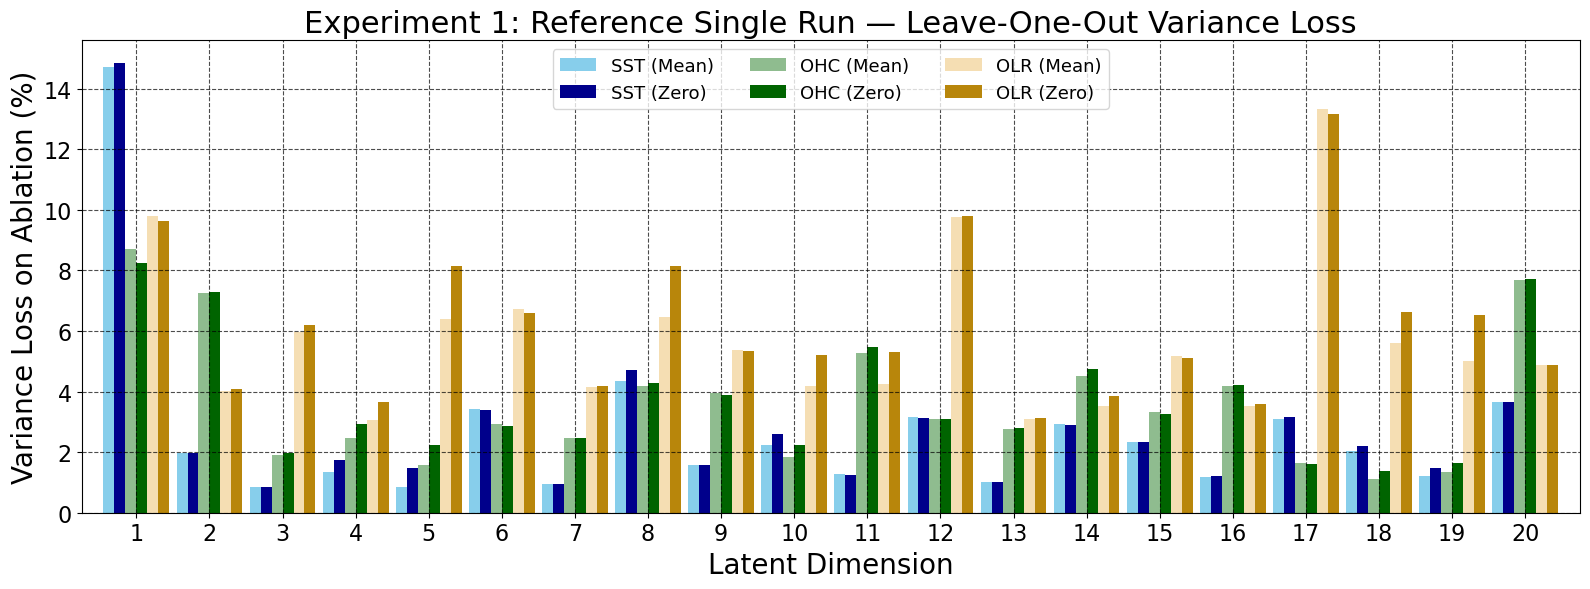

In [19]:
# Figure: Single-Run Experiment 1
plot_exp1(
    res        = singlerun_exp1,
    thresholds = thresholds,
    title      = 'Experiment 1: Reference Single Run — Leave-One-Out Variance Loss',
    #savepath   = 'exp1_singlerun.pdf'
)

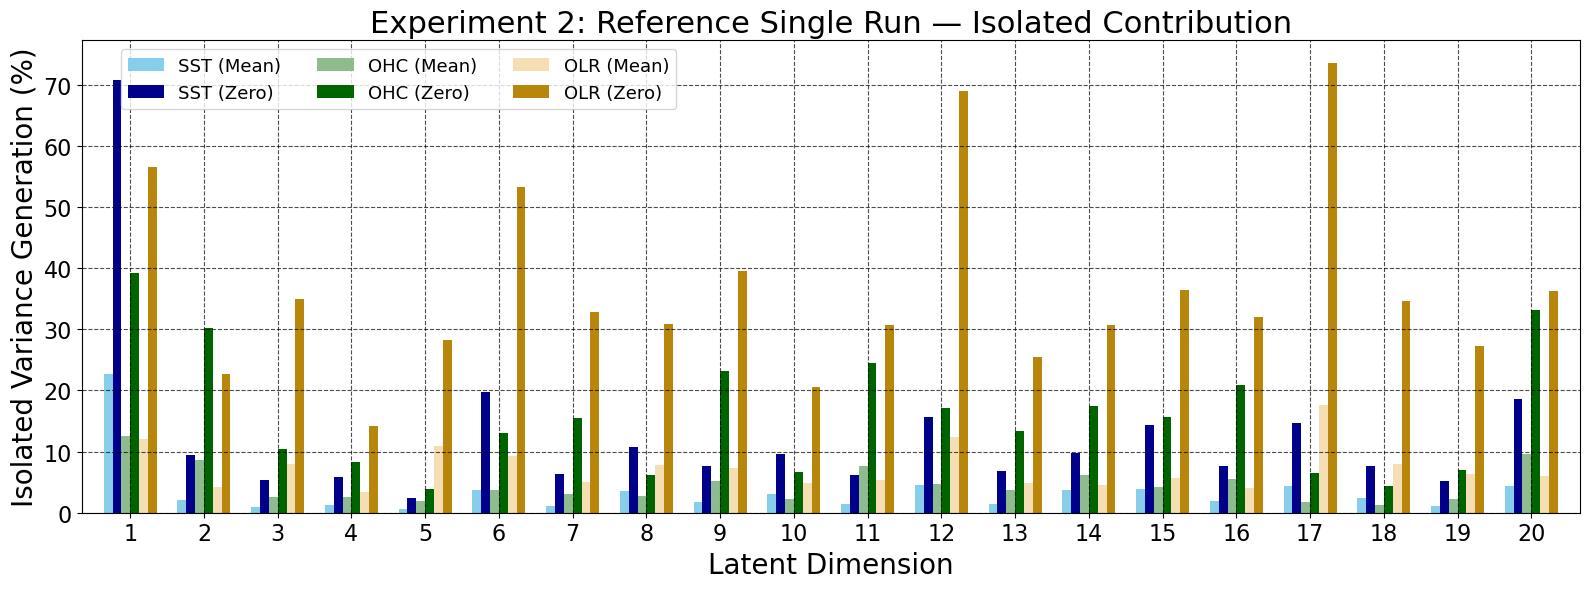

In [20]:
# Figure: Single-Run Experiment 2
plot_exp2(
    res      = singlerun_exp2,
    title    = 'Experiment 2: Reference Single Run — Isolated Contribution',
    #savepath = 'exp2_singlerun.pdf'
)

## Ensemble Approach A: Averaged Z-means (avgzmean)

> **What this does:** Loads pre-averaged ensemble z_means (already aligned and averaged
> across 50 runs), then ablates them through the single reference decoder.
>
> **Why it underestimates:** Averaging z_means across runs compresses variance in each
> dimension (Var(mean) ≈ Var/N). The reference decoder then sees lower-amplitude inputs
> and produces smaller variance changes upon ablation.

In [21]:
# load pre-averaged ensemble z_means
# test set only, already aligned across 50 runs
_ds_avg     = xr.open_dataset('latent_representations_ensemble_mean_0620.nc')
avgzmean_z  = _ds_avg['z_mean'].values

print(f"avgzmean z_means shape: {avgzmean_z.shape}  (should be 1200 x 20)")

avgzmean z_means shape: (1200, 20)  (should be 1200 x 20)


In [22]:
# experiment 1: avgzmean ablation
print("Running Experiment 1 on averaged z_means (Approach A)...")
avgzmean_exp1 = run_exp1_ablation(avgzmean_z, ref_predict)

# thresholds computed from single run — do not have to recompute here
print(f"\nNote: LD1 SST (mean) = {avgzmean_exp1['sst_mean'][0]:.1f}%  "
      f"(compare to single-run {singlerun_exp1['sst_mean'][0]:.1f}%)")

Running Experiment 1 on averaged z_means (Approach A)...
  LD   SST(mean)  SST(zero)   OHC(mean)  OHC(zero)   OLR(mean)  OLR(zero)
   1        8.4%       8.4%        5.6%       5.5%        8.1%       8.0%
   2        1.2%       1.2%        4.3%       4.3%        3.0%       3.1%
   3        0.5%       0.5%        1.1%       1.1%        4.2%       4.2%
   4        0.8%       0.8%        1.4%       1.5%        2.1%       2.1%
   5        0.5%       0.5%        1.1%       1.2%        7.2%       7.2%
   6        3.2%       3.2%        2.7%       2.6%        6.7%       6.6%
   7        0.5%       0.5%        1.3%       1.3%        2.9%       2.9%
   8        2.8%       2.7%        2.5%       2.3%        5.8%       6.1%
   9        0.9%       1.0%        2.6%       2.6%        4.1%       4.3%
  10        1.2%       1.2%        0.8%       0.8%        2.5%       2.6%
  11        0.8%       0.8%        3.6%       3.7%        4.0%       4.2%
  12        2.1%       2.1%        2.2%       2.2%     

Saved → exp1_avgzmean_0711.pdf


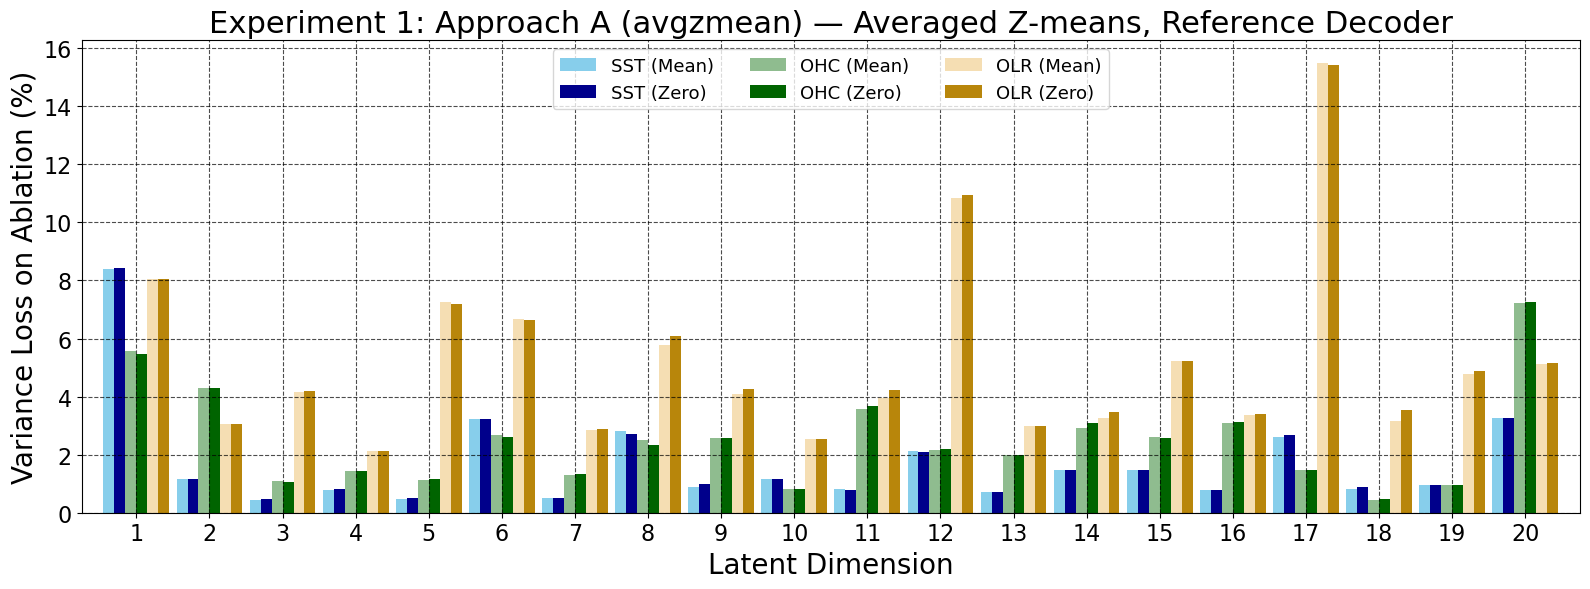

In [23]:
# approach A — avgzmean Experiment 1
plot_exp1(
    res        = avgzmean_exp1,
    thresholds = thresholds,
    title      = 'Experiment 1: Approach A (avgzmean) — Averaged Z-means, Reference Decoder',
    savepath   = 'exp1_avgzmean_0711.pdf'
)

## Ensemble Approach B: Per-Run Ablations (perrun)

> **What this does:**
> 1. For each of 50 runs, load that run's own decoder weights using `build_vae_with_decoder`.
> 2. Run ablation using that run's own z_means and its own decoder.
> 3. After ablation, re-order the 20 dimensions using an optimal permutation that aligns
>    each run's LD ordering to the reference single run (via max absolute correlation).
> 4. Average across 50 runs → bar heights. Std across 50 runs → error bars.
>
> **Alignment:** Uses `linear_sum_assignment` (optimal permutation matching) on the
> absolute Pearson correlation matrix between z_ref (reference run test set) and each
> run's z_means. This maps each run's LD to the reference LD it most resembles.

In [24]:
# step 1: compute alignment permutation for each run
from scipy.optimize import linear_sum_assignment
run_dir    = 'ensemble_runs_v2'
n_runs     = 50
latent_dim = 20

# sse seed-1 run as alignment reference
# same 1200 test samples as all other ensemble .npy files
z_ref = np.load(f'{run_dir}/z_mean_run01.npy')   # shape (1200, 20)

perm_indices = []
for run in range(n_runs):
    z_run = np.load(f'{run_dir}/z_mean_run{run:02d}.npy')
    corr_matrix = np.abs(np.corrcoef(z_ref.T, z_run.T)[:latent_dim, latent_dim:])
    _, col_ind  = linear_sum_assignment(-corr_matrix)
    perm_indices.append(col_ind)

print(f"Alignment permutations computed for {n_runs} runs.")
print(f"Run 01 permutation (reference run — should be identity [0,1,...,19]):")
print(f"  {perm_indices[1]}")

Alignment permutations computed for 50 runs.
Run 01 permutation (reference run — should be identity [0,1,...,19]):
  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [25]:
# DIAGNOSTIC: check alignment and weight loading for run 0

# 1. check shape of the .npy files
z_run00 = np.load(f'{run_dir}/z_mean_run00.npy')
print(f"z_mean_run00.npy shape: {z_run00.shape}")
print(f"z_ref shape:            {z_ref.shape}")
print(f"Shapes compatible for corrcoef: {z_run00.shape[0] == z_ref.shape[0]}")

# 2. check alignment quality for run 0
corr_matrix_00 = np.abs(np.corrcoef(z_ref.T, z_run00.T)[:latent_dim, latent_dim:])
print(f"\nRun 0 corr_matrix — max per reference column (how well each ref LD is matched):")
print(np.round(corr_matrix_00.max(axis=1), 3))
print(f"Permutation for run 0: {perm_indices[0]}")
print(f"Max correlation for ref LD1 (index 0): {corr_matrix_00[0].max():.3f}")

# 3. check weight loading
vae_test, decoder_test = build_vae_with_decoder(
    input_shape_sst, input_shape_ohc, input_shape_olr, latent_dim=latent_dim)
vae_test.load_weights(f'{run_dir}/vae_weights_run00.weights.h5')

r_sst, r_ohc, r_olr = decoder_test.predict(z_run00, verbose=0)
print(f"\nDecoder run 00 reconstruction variance (should be ~similar to single run):")
print(f"  SST var: {r_sst.reshape(len(z_run00), -1).var(axis=0).mean():.4f}")
print(f"  OHC var: {r_ohc.reshape(len(z_run00), -1).var(axis=0).mean():.4f}")
print(f"  OLR var: {r_olr.reshape(len(z_run00), -1).var(axis=0).mean():.4f}")

# 4. check reference decoder variance for comparison
r_sst_ref, _, _ = decoder_model.predict(z_ref, verbose=0)
print(f"  SST var (reference decoder): {r_sst_ref.reshape(len(z_ref), -1).var(axis=0).mean():.4f}")

del vae_test, decoder_test
keras.backend.clear_session()

z_mean_run00.npy shape: (1200, 20)
z_ref shape:            (1200, 20)
Shapes compatible for corrcoef: True

Run 0 corr_matrix — max per reference column (how well each ref LD is matched):
[0.646 0.681 0.582 0.351 0.531 0.554 0.646 0.583 0.552 0.553 0.584 0.63
 0.493 0.566 0.658 0.516 0.71  0.497 0.568 0.676]
Permutation for run 0: [13 17  7  1 18  0  2 19  5  8 14  3  9 16  6  4 12 11 10 15]
Max correlation for ref LD1 (index 0): 0.646



Decoder run 00 reconstruction variance (should be ~similar to single run):
  SST var: 0.8859
  OHC var: 0.6899
  OLR var: 0.8711
  SST var (reference decoder): 0.9415


In [26]:
# per-run ablations with each run's own decoder

# for each run:
#   a) build a VAE + decoder using build_vae_with_decoder
#   b) load that run's saved weights
#   c) run Exp 1 and Exp 2 ablations using the run's own z_means
#   d) re-order results using perm_indices[run] to align to reference
#   e) delete models and clear Keras session to free memory

# storage arrays: (n_runs, latent_dim)
all_exp1_sst_mean = np.zeros((n_runs, latent_dim))
all_exp1_sst_zero = np.zeros((n_runs, latent_dim))
all_exp1_ohc_mean = np.zeros((n_runs, latent_dim))
all_exp1_ohc_zero = np.zeros((n_runs, latent_dim))
all_exp1_olr_mean = np.zeros((n_runs, latent_dim))
all_exp1_olr_zero = np.zeros((n_runs, latent_dim))

all_exp2_sst_mean = np.zeros((n_runs, latent_dim))
all_exp2_sst_zero = np.zeros((n_runs, latent_dim))
all_exp2_ohc_mean = np.zeros((n_runs, latent_dim))
all_exp2_ohc_zero = np.zeros((n_runs, latent_dim))
all_exp2_olr_mean = np.zeros((n_runs, latent_dim))
all_exp2_olr_zero = np.zeros((n_runs, latent_dim))

for run in range(n_runs):
    # load this run's decoder
    weights_path = f'{run_dir}/vae_weights_run{run:02d}.weights.h5'
    vae_run, decoder_run = build_vae_with_decoder(
        input_shape_sst, input_shape_ohc, input_shape_olr, latent_dim=latent_dim)
    vae_run.load_weights(weights_path)
    # decoder_run now shares weights with vae_run, no separate weight loading needed

    # load this run's z_means (raw, unaligned)
    z_raw = np.load(f'{run_dir}/z_mean_run{run:02d}.npy')  # shape (N, 20)
    # pass decoder_run.predict as the prediction function
    def run_predict(z, _dec=decoder_run):
        return _dec.predict(z, verbose=0)

    # Experiment 1
    exp1 = run_exp1_ablation(z_raw, run_predict, verbose=False)
    all_exp1_sst_mean[run] = exp1['sst_mean']
    all_exp1_sst_zero[run] = exp1['sst_zero']
    all_exp1_ohc_mean[run] = exp1['ohc_mean']
    all_exp1_ohc_zero[run] = exp1['ohc_zero']
    all_exp1_olr_mean[run] = exp1['olr_mean']
    all_exp1_olr_zero[run] = exp1['olr_zero']

    # Experiment 2
    exp2 = run_exp2_ablation(z_raw, run_predict, verbose=False)
    all_exp2_sst_mean[run] = exp2['sst_mean']
    all_exp2_sst_zero[run] = exp2['sst_zero']
    all_exp2_ohc_mean[run] = exp2['ohc_mean']
    all_exp2_ohc_zero[run] = exp2['ohc_zero']
    all_exp2_olr_mean[run] = exp2['olr_mean']
    all_exp2_olr_zero[run] = exp2['olr_zero']

    # re-order dimensions to align to reference
    col_ind = perm_indices[run]
    all_exp1_sst_mean[run] = all_exp1_sst_mean[run][col_ind]
    all_exp1_sst_zero[run] = all_exp1_sst_zero[run][col_ind]
    all_exp1_ohc_mean[run] = all_exp1_ohc_mean[run][col_ind]
    all_exp1_ohc_zero[run] = all_exp1_ohc_zero[run][col_ind]
    all_exp1_olr_mean[run] = all_exp1_olr_mean[run][col_ind]
    all_exp1_olr_zero[run] = all_exp1_olr_zero[run][col_ind]
    all_exp2_sst_mean[run] = all_exp2_sst_mean[run][col_ind]
    all_exp2_sst_zero[run] = all_exp2_sst_zero[run][col_ind]
    all_exp2_ohc_mean[run] = all_exp2_ohc_mean[run][col_ind]
    all_exp2_ohc_zero[run] = all_exp2_ohc_zero[run][col_ind]
    all_exp2_olr_mean[run] = all_exp2_olr_mean[run][col_ind]
    all_exp2_olr_zero[run] = all_exp2_olr_zero[run][col_ind]

    # free memory (if needed)
    del vae_run, decoder_run
    keras.backend.clear_session()
    print(f"Run {run+1:2d}/{n_runs} done")

print("\nAll runs complete.")

Run  1/50 done


Run  2/50 done


Run  3/50 done


Run  4/50 done


Run  5/50 done


...

Run 46/50 done


Run 47/50 done


Run 48/50 done


Run 49/50 done


Run 50/50 done

All runs complete.


In [27]:
all_exp1_sst_mean.shape

(50, 20)

In [28]:
# compute per-run means (bar heights) and stds (error bars)

perrun_exp1 = {
    'sst_mean': all_exp1_sst_mean.mean(axis=0),
    'sst_zero': all_exp1_sst_zero.mean(axis=0),
    'ohc_mean': all_exp1_ohc_mean.mean(axis=0),
    'ohc_zero': all_exp1_ohc_zero.mean(axis=0),
    'olr_mean': all_exp1_olr_mean.mean(axis=0),
    'olr_zero': all_exp1_olr_zero.mean(axis=0),
}

perrun_exp1_std = {
    'sst_mean': all_exp1_sst_mean.std(axis=0),
    'sst_zero': all_exp1_sst_zero.std(axis=0),
    'ohc_mean': all_exp1_ohc_mean.std(axis=0),
    'ohc_zero': all_exp1_ohc_zero.std(axis=0),
    'olr_mean': all_exp1_olr_mean.std(axis=0),
    'olr_zero': all_exp1_olr_zero.std(axis=0),
}

perrun_exp2 = {
    'sst_mean': all_exp2_sst_mean.mean(axis=0),
    'sst_zero': all_exp2_sst_zero.mean(axis=0),
    'ohc_mean': all_exp2_ohc_mean.mean(axis=0),
    'ohc_zero': all_exp2_ohc_zero.mean(axis=0),
    'olr_mean': all_exp2_olr_mean.mean(axis=0),
    'olr_zero': all_exp2_olr_zero.mean(axis=0),
}

perrun_exp2_std = {
    'sst_mean': all_exp2_sst_mean.std(axis=0),
    'sst_zero': all_exp2_sst_zero.std(axis=0),
    'ohc_mean': all_exp2_ohc_mean.std(axis=0),
    'ohc_zero': all_exp2_ohc_zero.std(axis=0),
    'olr_mean': all_exp2_olr_mean.std(axis=0),
    'olr_zero': all_exp2_olr_zero.std(axis=0),
}

# sanity check: compare LD1 SST across approaches
print("=" * 60)
print(f"  LD1 SST (mean-replacement) across approaches:")
print(f"  Single run  :  {singlerun_exp1['sst_mean'][0]:.1f}%")
print(f"  avgzmean    :  {avgzmean_exp1['sst_mean'][0]:.1f}%   ← compressed by averaging")
print(f"  perrun mean :  {perrun_exp1['sst_mean'][0]:.1f}%  ± {perrun_exp1_std['sst_mean'][0]:.1f}%  ← paper figure")
print("=" * 60)

  LD1 SST (mean-replacement) across approaches:
  Single run  :  14.7%
  avgzmean    :  8.4%   ← compressed by averaging
  perrun mean :  6.1%  ± 5.8%  ← paper figure


In [29]:
all_exp1_sst_mean.shape

(50, 20)

In [30]:
# what does the reference run give through the per-run loop?
print(f"Run 01 LD1 SST: {all_exp1_sst_mean[1][0]:.1f}%")

# what is the MAX ablation score for any LD in each run (before alignment matters)?
for run in range(50):
    print(f"Run {run:02d} — max SST across all LDs: {all_exp1_sst_mean[run].max():.1f}%  "
          f"(at LD index {all_exp1_sst_mean[run].argmax()})")

Run 01 LD1 SST: 14.3%
Run 00 — max SST across all LDs: 5.9%  (at LD index 14)
Run 01 — max SST across all LDs: 14.3%  (at LD index 0)
Run 02 — max SST across all LDs: 8.6%  (at LD index 7)
Run 03 — max SST across all LDs: 7.8%  (at LD index 0)
Run 04 — max SST across all LDs: 7.4%  (at LD index 16)
Run 05 — max SST across all LDs: 17.0%  (at LD index 5)
Run 06 — max SST across all LDs: 16.5%  (at LD index 0)
Run 07 — max SST across all LDs: 11.6%  (at LD index 0)
Run 08 — max SST across all LDs: 10.9%  (at LD index 5)
Run 09 — max SST across all LDs: 8.8%  (at LD index 11)
Run 10 — max SST across all LDs: 9.0%  (at LD index 17)
Run 11 — max SST across all LDs: 13.1%  (at LD index 16)
Run 12 — max SST across all LDs: 8.1%  (at LD index 16)
Run 13 — max SST across all LDs: 7.2%  (at LD index 7)
Run 14 — max SST across all LDs: 7.1%  (at LD index 2)
Run 15 — max SST across all LDs: 11.8%  (at LD index 2)
Run 16 — max SST across all LDs: 11.3%  (at LD index 16)
Run 17 — max SST across all 

In [29]:
# ── Investigate outlier runs ──────────────────────────────────────────────────
suspect_runs = [31, 33, 20, 36, 38]  # high outliers

for run in suspect_runs:
    z_run = np.load(f'{run_dir}/z_mean_run{run:02d}.npy')
    
    # Load decoder
    vae_check, decoder_check = build_vae_with_decoder(
        input_shape_sst, input_shape_ohc, input_shape_olr, latent_dim=latent_dim)
    vae_check.load_weights(f'{run_dir}/vae_weights_run{run:02d}.weights.h5')
    
    r_sst, r_ohc, r_olr = decoder_check.predict(z_run, verbose=0)
    
    full_var   = r_sst.reshape(len(z_run), -1).var(axis=0).mean()
    z_var      = z_run.var(axis=0)          # variance of each LD
    z_mean_val = z_run.mean(axis=0)         # mean of each LD
    
    best_ld    = all_exp1_sst_mean[run].argmax()
    best_score = all_exp1_sst_mean[run].max()
    
    print(f"\nRun {run:02d} — best LD={best_ld}, score={best_score:.1f}%")
    print(f"  Full recon SST var:     {full_var:.4f}  (run01 reference: ~0.89)")
    print(f"  z_run var at best LD:   {z_var[best_ld]:.4f}")
    print(f"  z_run mean at best LD:  {z_mean_val[best_ld]:.4f}")
    print(f"  All SST scores (aligned): {np.round(all_exp1_sst_mean[run], 1)}")
    
    del vae_check, decoder_check
    keras.backend.clear_session()


Run 31 — best LD=7, score=40.7%
  Full recon SST var:     0.8523  (run01 reference: ~0.89)
  z_run var at best LD:   0.3756
  z_run mean at best LD:  -0.3196
  All SST scores (aligned): [ 1.8  1.2  2.5  1.1  0.6  3.4  0.8 40.7  1.3  2.2  0.7  1.7  2.1  3.3
  1.4  1.5  0.8  0.9  1.   1.3]



Run 33 — best LD=0, score=30.6%
  Full recon SST var:     0.8665  (run01 reference: ~0.89)
  z_run var at best LD:   0.3459
  z_run mean at best LD:  0.0424
  All SST scores (aligned): [30.6  0.8  1.4  1.4  1.   2.8  1.4  0.9  1.   2.6  1.9  1.5  1.2  1.4
  1.5  0.7  7.3  1.1  0.9  1.4]



Run 20 — best LD=16, score=26.9%
  Full recon SST var:     0.8433  (run01 reference: ~0.89)
  z_run var at best LD:   0.3682
  z_run mean at best LD:  0.1545
  All SST scores (aligned): [ 1.4  1.5  1.2  0.6  2.1  3.   1.6  4.   3.4  3.8  1.2  1.2  2.   1.2
  1.3  2.4 26.9  1.7  0.8  1.1]



Run 36 — best LD=0, score=26.3%
  Full recon SST var:     0.8539  (run01 reference: ~0.89)
  z_run var at best LD:   0.9043
  z_run mean at best LD:  0.5479
  All SST scores (aligned): [26.3  1.2  1.   1.   1.6  0.9  0.8  1.5  1.4  0.7  2.1  1.5  1.3  1.7
  1.7  1.2 15.8  3.3  1.1  1.6]



Run 38 — best LD=16, score=24.6%
  Full recon SST var:     0.9458  (run01 reference: ~0.89)
  z_run var at best LD:   0.3635
  z_run mean at best LD:  0.3154
  All SST scores (aligned): [ 3.   1.   1.5  1.2  4.5  0.8  0.7  1.1  2.8  0.7  1.8  6.7  0.6  2.4
  5.   1.2 24.6  0.4  1.5  1.3]


Saved → exp1_perrun_mean_0711.pdf


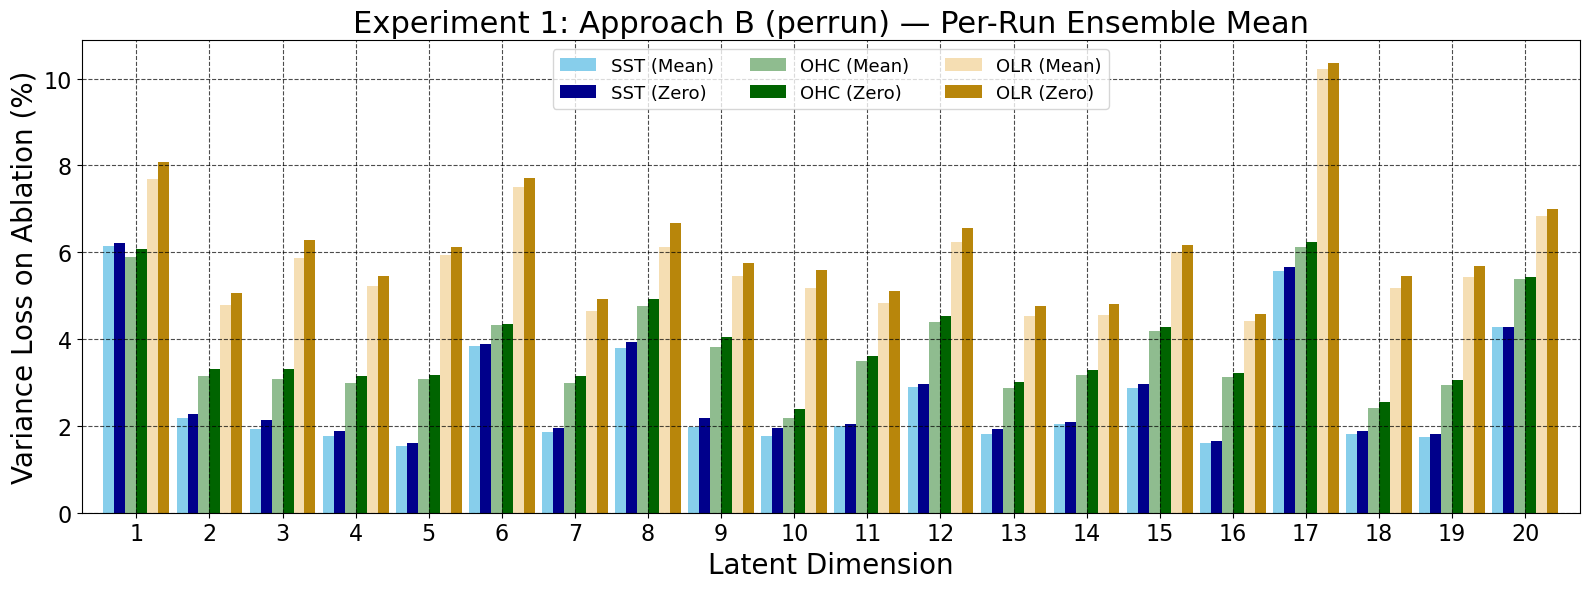

In [31]:
# Per-Run Ensemble Mean (no error bars)
plot_exp1(
    res        = perrun_exp1,
    #thresholds = thresholds,
    title      = 'Experiment 1: Approach B (perrun) — Per-Run Ensemble Mean',
    savepath   = 'exp1_perrun_mean_0711.pdf'
)

Saved → exp1_perrun_mean_std_0711.pdf


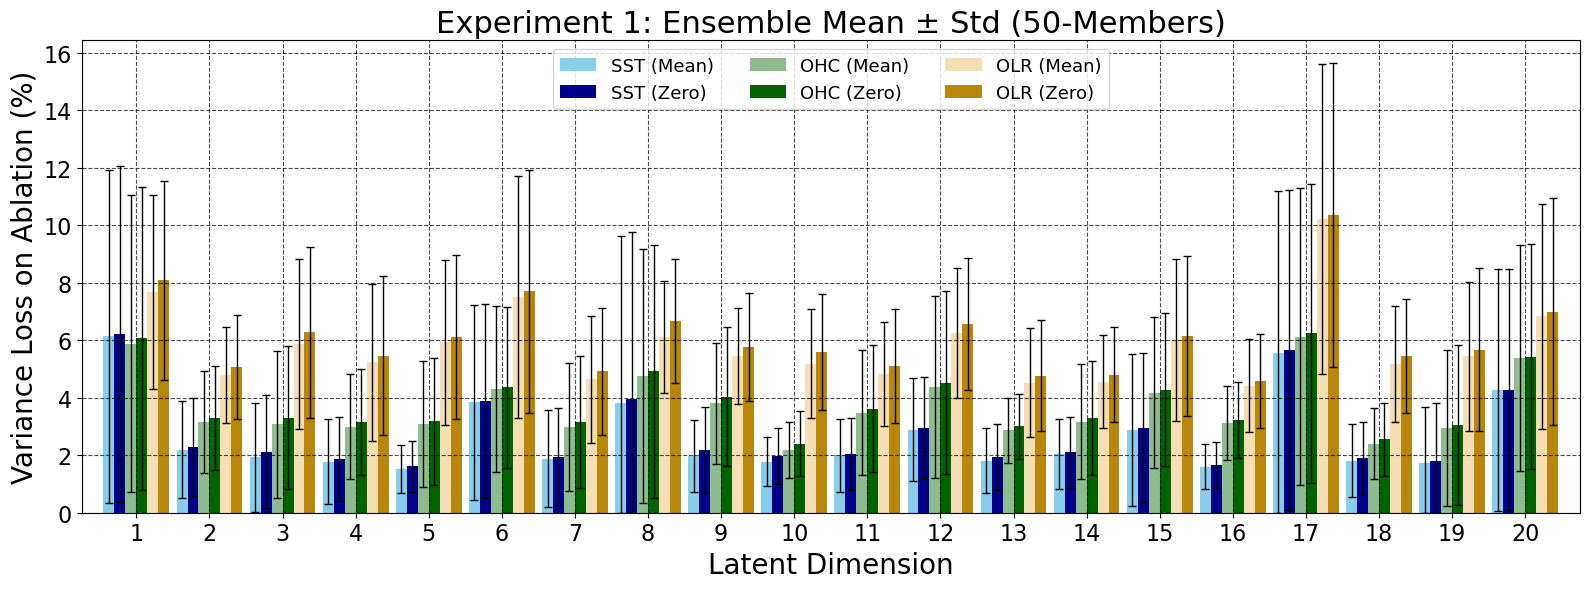

In [32]:
# Per-Run Ensemble Mean ± Std
plot_exp1(
    res        = perrun_exp1,
    #thresholds = thresholds,
    std_res    = perrun_exp1_std,
    title      = 'Experiment 1: Ensemble Mean ± Std (50-Members)',
    savepath   = 'exp1_perrun_mean_std_0711.pdf'
)

## Experiment 2: Isolated Contribution

Single-run Experiment 2 uses the reference z_means through the reference decoder.

> **Note on per-run Experiment 2:** Using each run's own decoder with only one
> active LD (all others zeroed or set to mean) pushes the decoder far outside its
> training distribution, making reconstructions unreliable. For this reason,
> only single-run Experiment 2 is shown

Saved → exp2_singlerun_0711.pdf


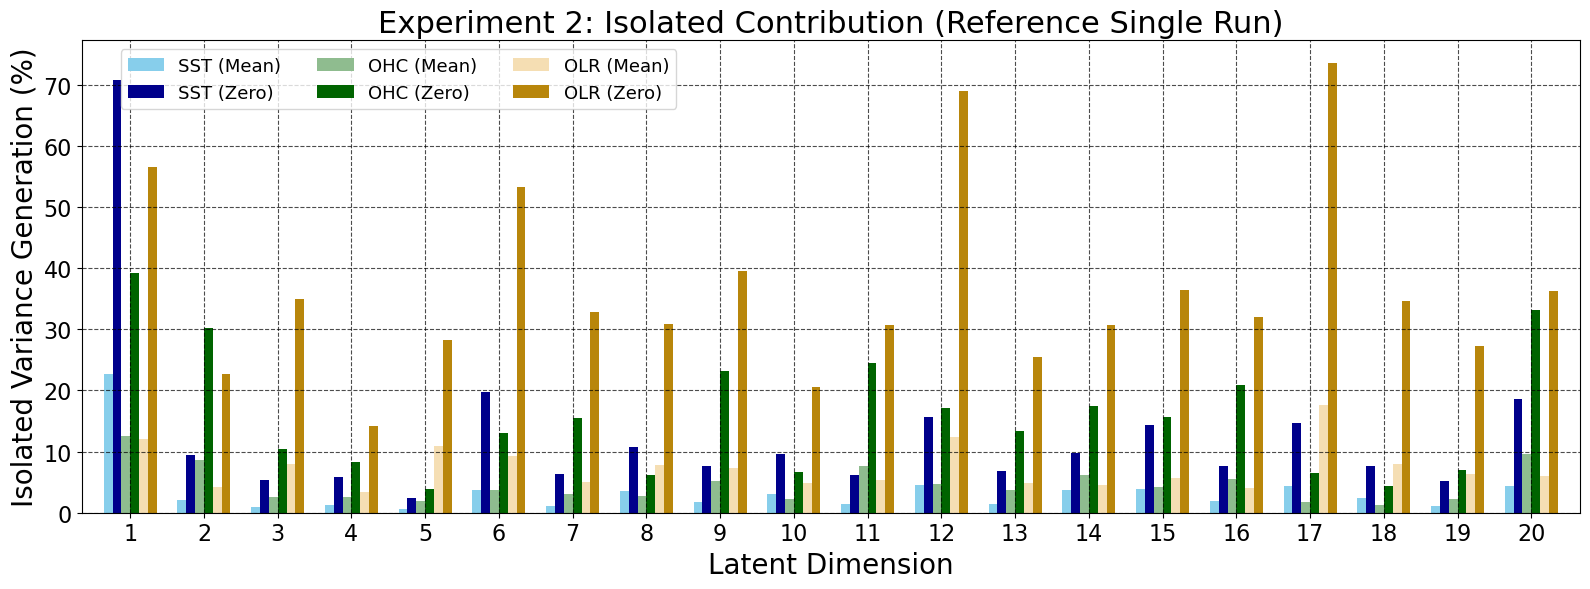

In [33]:
# Experiment 2 — Single Run (reference)

plot_exp2(
    res      = singlerun_exp2,
    title    = 'Experiment 2: Isolated Contribution (Reference Single Run)',
    savepath = 'exp2_singlerun_0711.pdf'
)

Saved → exp2_perrun_mean_std_0711.pdf


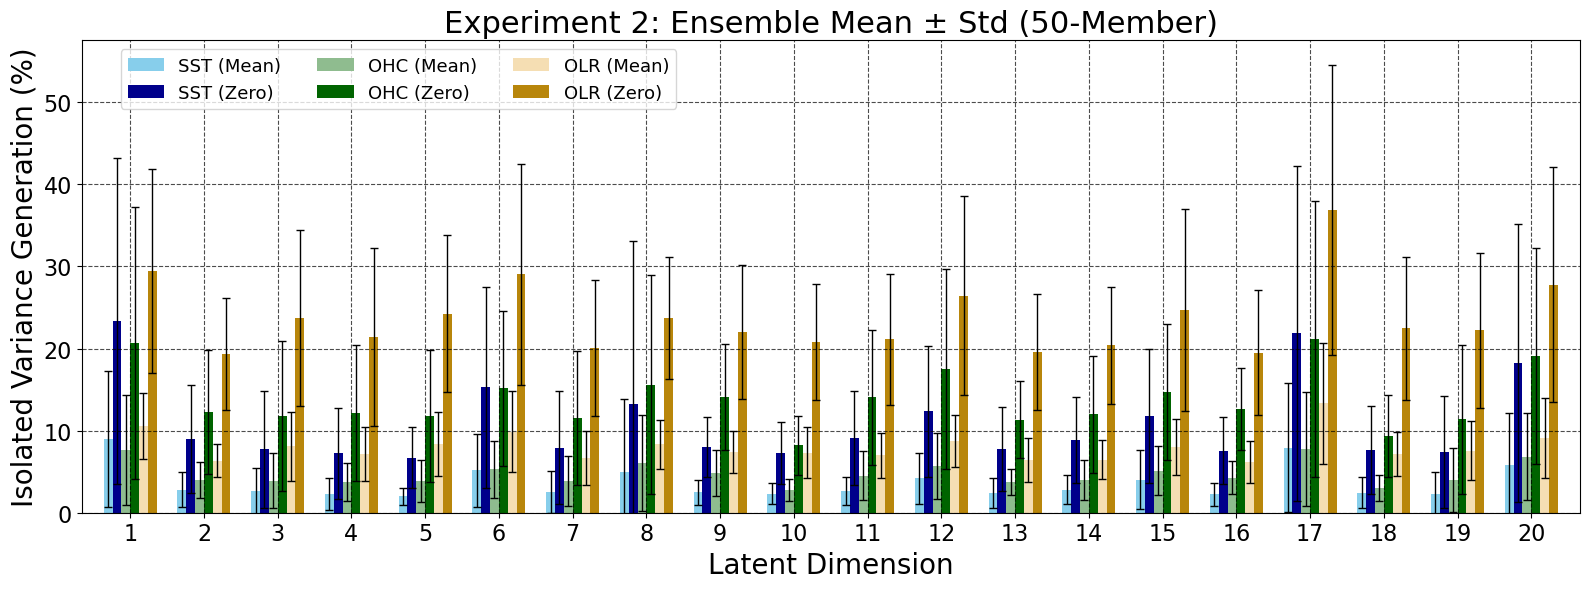

In [34]:
# Experiment 2 — Per-Run Ensemble with Error Bars

plot_exp2(
    res      = perrun_exp2,
    std_res  = perrun_exp2_std,
    title    = 'Experiment 2: Ensemble Mean ± Std (50-Member)',
    savepath = 'exp2_perrun_mean_std_0711.pdf'
)

## Appendix Box Plot

Max SST — mean: 12.6% ± 6.8%
Max OHC — mean: 13.0% ± 4.8%
Max OLR — mean: 14.9% ± 3.8%


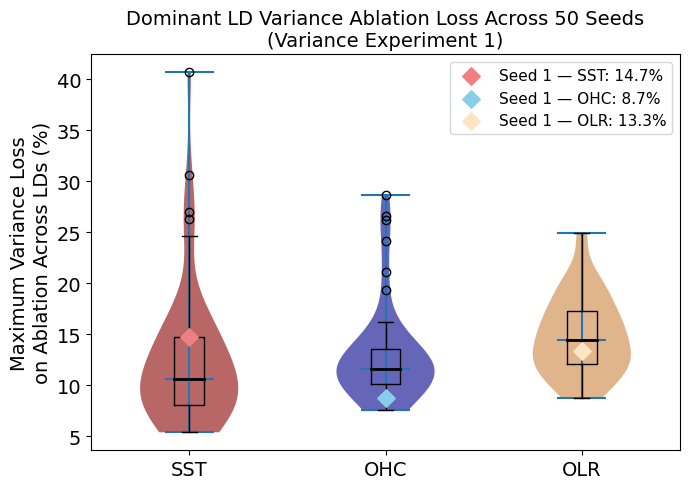

Saved ensemble_max_ablation_violin.pdf


In [35]:
# per-run max ablation scores (best LD per run, across all variables)
max_sst = np.array([all_exp1_sst_mean[r].max() for r in range(n_runs)])
max_ohc = np.array([all_exp1_ohc_mean[r].max() for r in range(n_runs)])
max_olr = np.array([all_exp1_olr_mean[r].max() for r in range(n_runs)])

print(f"Max SST — mean: {max_sst.mean():.1f}% ± {max_sst.std():.1f}%")
print(f"Max OHC — mean: {max_ohc.mean():.1f}% ± {max_ohc.std():.1f}%")
print(f"Max OLR — mean: {max_olr.mean():.1f}% ± {max_olr.std():.1f}%")

# panel a figure
fig, ax = plt.subplots(figsize=(7, 5))

data   = [max_sst, max_ohc, max_olr]
labels = ['SST', 'OHC', 'OLR']
colors = ['darkred', 'darkblue', 'peru']

# violin
parts = ax.violinplot(data, positions=[1, 2, 3], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)

# box overlay
ax.boxplot(data, positions=[1, 2, 3], widths=0.15,
           patch_artist=False, showfliers=True,
           medianprops=dict(color='black', linewidth=2))

ref_sst = singlerun_exp1['sst_mean'].max()
ref_ohc = singlerun_exp1['ohc_mean'].max()
ref_olr = singlerun_exp1['olr_mean'].max()

ax.scatter([1], [ref_sst], color='lightcoral', zorder=5, s=80, marker='D',
           label=f'Seed 1 — SST: {ref_sst:.1f}%')
ax.scatter([2], [ref_ohc], color='skyblue', zorder=5, s=80, marker='D',
           label=f'Seed 1 — OHC: {ref_ohc:.1f}%')
ax.scatter([3], [ref_olr], color='bisque', zorder=5, s=80, marker='D',
           label=f'Seed 1 — OLR: {ref_olr:.1f}%')

ax.legend(fontsize=11)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel('Maximum Variance Loss\non Ablation Across LDs (%)', fontsize=14)
ax.set_title('Dominant LD Variance Ablation Loss Across 50 Seeds\n(Variance Experiment 1)',
             fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('ensemble_max_ablation_violin_0711.pdf', bbox_inches='tight')
plt.show()
print("Saved ensemble_max_ablation_violin.pdf")

Max SST — mean: 18.1% ± 9.8%
Max OHC — mean: 16.7% ± 6.5%
Max OLR — mean: 19.4% ± 5.3%


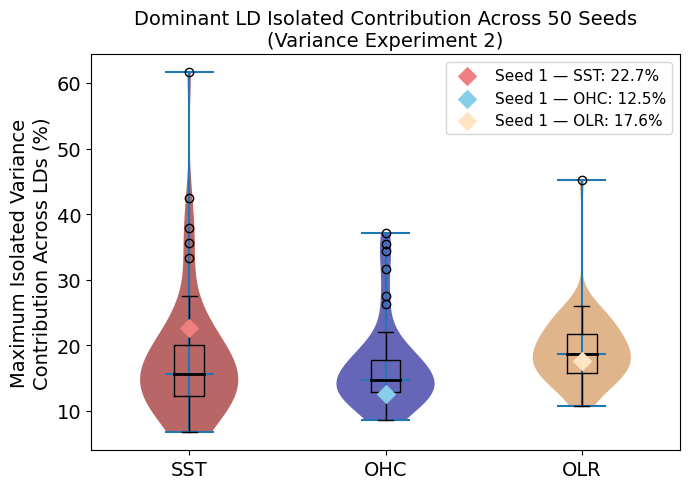

In [36]:
# per-run max isolated contribution (Exp 2)
max_sst2 = np.array([all_exp2_sst_mean[r].max() for r in range(n_runs)])
max_ohc2 = np.array([all_exp2_ohc_mean[r].max() for r in range(n_runs)])
max_olr2 = np.array([all_exp2_olr_mean[r].max() for r in range(n_runs)])

print(f"Max SST — mean: {max_sst2.mean():.1f}% ± {max_sst2.std():.1f}%")
print(f"Max OHC — mean: {max_ohc2.mean():.1f}% ± {max_ohc2.std():.1f}%")
print(f"Max OLR — mean: {max_olr2.mean():.1f}% ± {max_olr2.std():.1f}%")

# panel b figure
fig, ax = plt.subplots(figsize=(7, 5))

data   = [max_sst2, max_ohc2, max_olr2]
labels = ['SST', 'OHC', 'OLR']
colors = ['darkred', 'darkblue', 'peru']

parts = ax.violinplot(data, positions=[1, 2, 3], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.6)

ax.boxplot(data, positions=[1, 2, 3], widths=0.15,
           patch_artist=False, showfliers=True,
           medianprops=dict(color='black', linewidth=2))

ref_sst2 = singlerun_exp2['sst_mean'].max()
ref_ohc2 = singlerun_exp2['ohc_mean'].max()
ref_olr2 = singlerun_exp2['olr_mean'].max()

ax.scatter([1], [ref_sst2], color='lightcoral', zorder=5, s=80, marker='D',
           label=f'Seed 1 — SST: {ref_sst2:.1f}%')
ax.scatter([2], [ref_ohc2], color='skyblue',   zorder=5, s=80, marker='D',
           label=f'Seed 1 — OHC: {ref_ohc2:.1f}%')
ax.scatter([3], [ref_olr2], color='bisque',    zorder=5, s=80, marker='D',
           label=f'Seed 1 — OLR: {ref_olr2:.1f}%')

ax.legend(fontsize=11)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel('Maximum Isolated Variance\nContribution Across LDs (%)', fontsize=14)
ax.set_title('Dominant LD Isolated Contribution Across 50 Seeds\n(Variance Experiment 2)', fontsize=14)

plt.tight_layout()
plt.savefig('ensemble_max_isolated_violin_0711.pdf', bbox_inches='tight')
plt.show()

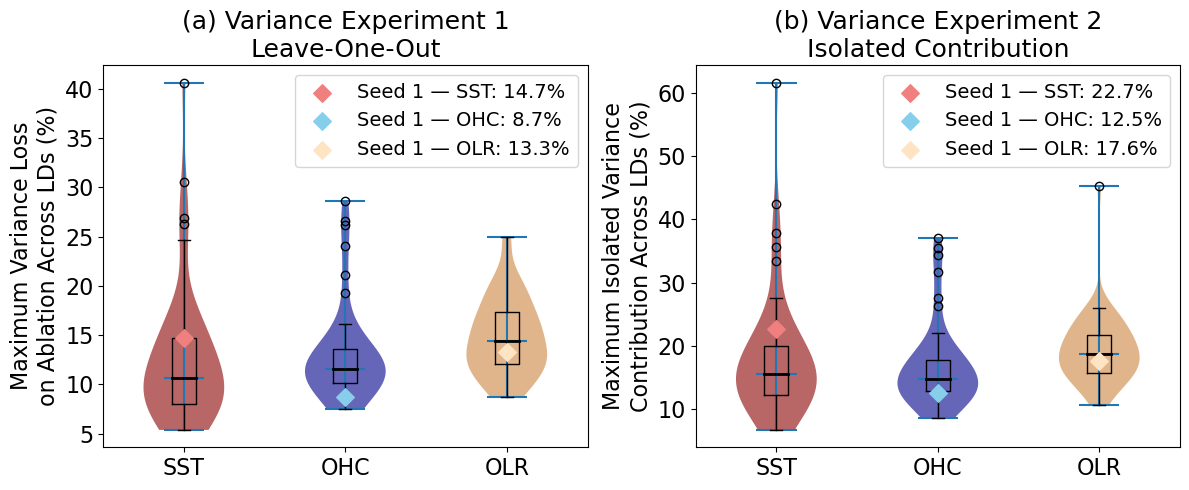

In [37]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 5))

# panel a
data_a   = [max_sst, max_ohc, max_olr]
parts = ax_a.violinplot(data_a, positions=[1, 2, 3], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_alpha(0.6)
ax_a.boxplot(data_a, positions=[1, 2, 3], widths=0.15,
             patch_artist=False, showfliers=True,
             medianprops=dict(color='black', linewidth=2))
ax_a.scatter([1], [ref_sst], color='lightcoral', zorder=5, s=80, marker='D',
             label=f'Seed 1 — SST: {ref_sst:.1f}%')
ax_a.scatter([2], [ref_ohc], color='skyblue',   zorder=5, s=80, marker='D',
             label=f'Seed 1 — OHC: {ref_ohc:.1f}%')
ax_a.scatter([3], [ref_olr], color='bisque',    zorder=5, s=80, marker='D',
             label=f'Seed 1 — OLR: {ref_olr:.1f}%')
ax_a.set_xticks([1, 2, 3]); ax_a.set_xticklabels(labels, fontsize=16)
ax_a.tick_params(axis='both', labelsize=16)
ax_a.set_ylabel('Maximum Variance Loss\non Ablation Across LDs (%)', fontsize=16)
ax_a.set_title('(a) Variance Experiment 1\nLeave-One-Out', fontsize=18)
ax_a.legend(fontsize=14)

# panel b
data_b = [max_sst2, max_ohc2, max_olr2]
parts = ax_b.violinplot(data_b, positions=[1, 2, 3], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_alpha(0.6)
ax_b.boxplot(data_b, positions=[1, 2, 3], widths=0.15,
             patch_artist=False, showfliers=True,
             medianprops=dict(color='black', linewidth=2))
ax_b.scatter([1], [ref_sst2], color='lightcoral', zorder=5, s=80, marker='D',
             label=f'Seed 1 — SST: {ref_sst2:.1f}%')
ax_b.scatter([2], [ref_ohc2], color='skyblue',    zorder=5, s=80, marker='D',
             label=f'Seed 1 — OHC: {ref_ohc2:.1f}%')
ax_b.scatter([3], [ref_olr2], color='bisque',     zorder=5, s=80, marker='D',
             label=f'Seed 1 — OLR: {ref_olr2:.1f}%')
ax_b.set_xticks([1, 2, 3]); ax_b.set_xticklabels(labels, fontsize=16)
ax_b.tick_params(axis='both', labelsize=16)
ax_b.set_ylabel('Maximum Isolated Variance\nContribution Across LDs (%)', fontsize=16)
ax_b.set_title('(b) Variance Experiment 2\nIsolated Contribution', fontsize=18)
ax_b.legend(fontsize=14)

plt.tight_layout()
plt.savefig('ensemble_max_ablation_panels_0711.pdf', bbox_inches='tight')
plt.show()